In [7]:
import pandas as pd
import numpy as np
import scipy.stats as stats

In [2]:
# load scr data
df = pd.read_csv('data/scr_brain_group.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4485 entries, 0 to 4484
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sub           4485 non-null   object 
 1   Condition     4485 non-null   object 
 2   Event.Nr      4485 non-null   int64  
 3   CDA.AmpSum    4485 non-null   float64
 4   pe            4485 non-null   float64
 5   scr           4485 non-null   float64
 6   index         4485 non-null   int64  
 7   subject       4485 non-null   object 
 8   trialNo       4485 non-null   int64  
 9   condition     4485 non-null   object 
 10  coupling      4485 non-null   float64
 11  amg           4485 non-null   float64
 12  amg_vmpfc     4485 non-null   float64
 13  sub_id        4485 non-null   object 
 14  group         4485 non-null   object 
 15  Gender        4485 non-null   float64
 16  Age           4485 non-null   float64
 17  n_zero_scr_x  4485 non-null   int64  
 18  n_zero_scr_y  4485 non-null 

In [3]:
np.sum(df[df['sub']=='sub-189'].scr.values==0)

np.int64(15)

In [4]:
df[df['sub']=='sub-189'].scr.values==0

array([False, False, False, False,  True,  True,  True,  True, False,
        True, False, False, False,  True, False,  True, False, False,
       False, False,  True,  True,  True, False, False, False,  True,
        True,  True,  True, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False,  True,
       False, False, False, False, False, False])

In [5]:
# descriptive table: number/percent of zero-scr trials per group
zero_table = (
    df.groupby('group')['scr']
    .agg(n_total='size', n_zero=lambda s: (s == 0).sum())
    .assign(pct_zero=lambda t: (t['n_zero'] / t['n_total'] * 100).round(2))
    .reset_index()
)
zero_table

,group,n_total,n_zero,pct_zero
0,HC,1311,286,21.82
1,VCC,1725,345,20.00
2,VPTSD,1449,506,34.92


In [6]:
# step 1: number of zero-scr trials per subject (69 trials each)
subj_zero = (
    df.groupby(['group', 'sub'])['scr']
    .agg(n_trials='size', n_zero=lambda s: (s == 0).sum())
    .assign(pct_zero=lambda t: (t['n_zero'] / t['n_trials'] * 100).round(2))
    .reset_index()
)
subj_zero

,group,sub,n_trials,n_zero,pct_zero
0,HC,sub-100,69,0,0.00
1,HC,sub-126,69,24,34.78
2,HC,sub-130,69,2,2.90
3,HC,sub-150,69,7,10.14
4,HC,sub-152,69,49,71.01
...,...,...,...,...,...
60,VPTSD,sub-177,69,32,46.38
61,VPTSD,sub-179,69,22,31.88
62,VPTSD,sub-203,69,27,39.13
63,VPTSD,sub-204,69,7,10.14


In [13]:
subj_zero

,group,sub,n_trials,n_zero,pct_zero
0,HC,sub-100,69,0,0.00
1,HC,sub-126,69,24,34.78
2,HC,sub-130,69,2,2.90
3,HC,sub-150,69,7,10.14
4,HC,sub-152,69,49,71.01
...,...,...,...,...,...
60,VPTSD,sub-177,69,32,46.38
61,VPTSD,sub-179,69,22,31.88
62,VPTSD,sub-203,69,27,39.13
63,VPTSD,sub-204,69,7,10.14


In [20]:
# total (based on percent zero-SCR per subject)
total_zero_summary = pd.DataFrame([{
    'n_subjects': subj_zero['pct_zero'].count(),
    'mean': round((100 - subj_zero['pct_zero']).mean(), 2),
    'sd': round((100 - subj_zero['pct_zero']).std(), 2),
    'median': round((100 - subj_zero['pct_zero']).median(), 2),
    'min': (100 - subj_zero['pct_zero']).min(),
    'max': (100 - subj_zero['pct_zero']).max(),
    'q1': round(np.percentile(100 - subj_zero['pct_zero'], 25), 2),
    'q3': round(np.percentile(100 - subj_zero['pct_zero'], 75), 2),
}])

total_zero_summary

,n_subjects,mean,sd,median,min,max,q1,q3
0,65,74.65,24.59,82.61,10.14,100.0,63.77,94.2


In [8]:
# step 2: summarize per-subject zero counts within each group

group_zero_summary = (
    subj_zero.groupby('group')['n_zero']
    .agg(n_subjects='count', mean='mean', sd='std', median='median', min='min', max='max', q1=lambda x: np.percentile(x, 25), q3=lambda x: np.percentile(x, 75))
    .round(2)
    .reset_index()
)
group_zero_summary

,group,n_subjects,mean,sd,median,min,max,q1,q3
0,HC,19,15.05,16.68,8.0,0,56,3.0,20.5
1,VCC,25,13.80,16.52,8.0,0,58,2.0,19.0
2,VPTSD,21,24.10,16.58,24.0,0,62,11.0,32.0


In [11]:
# add per-subject zero-scr trial count back into the original csv
df = df.merge(subj_zero[['sub', 'n_zero']].rename(columns={'n_zero': 'n_zero_scr'}), on='sub', how='left')
df.to_csv('data/scr_brain_group.csv', index=False)
df.head()

,sub,Condition,Event.Nr,CDA.AmpSum,pe,scr,index,subject,trialNo,condition,coupling,amg,amg_vmpfc,sub_id,group,Gender,Age,n_zero_scr_x,n_zero_scr_y
0,sub-189,CSplusUS1,1,0.2852,0.500000,0.2852,3036,sub-189,1,CSplusUS1,0.904762,0.476625,0.833333,sub-189,HC,2.0,26.0,15,15
1,sub-189,CSminus1,2,0.1033,-0.500000,0.1033,3037,sub-189,2,CSminus1,-0.380952,0.081692,0.428571,sub-189,HC,2.0,26.0,15,15
2,sub-189,CSplus1,3,0.0783,-0.750000,0.0783,3038,sub-189,3,CSplus1,0.571429,-0.219659,0.690476,sub-189,HC,2.0,26.0,15,15
3,sub-189,CSplusUS1,4,0.1772,0.686106,0.1772,3039,sub-189,4,CSplusUS1,0.619048,0.006618,0.880952,sub-189,HC,2.0,26.0,15,15
4,sub-189,CSminus1,5,0.0000,-0.250000,0.0000,3040,sub-189,5,CSminus1,0.833333,-0.188212,0.595238,sub-189,HC,2.0,26.0,15,15


<Axes: >

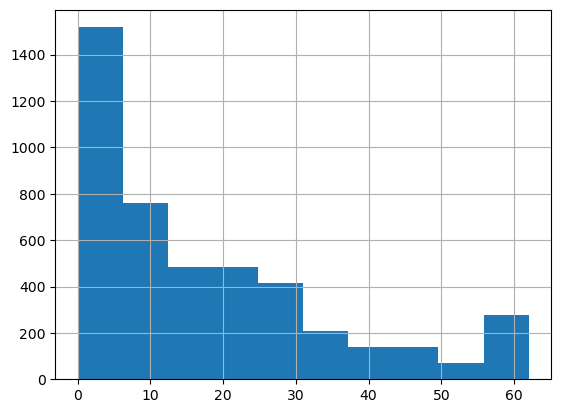

In [7]:
df['n_zero_scr'].hist()

In [23]:
import pymc as pm
import arviz as az

# Use existing per-subject table: subj_zero (one row per subject)
d = subj_zero.copy()

# Stable group order for interpretation
group_order = ["HC", "VCC", "VPTSD"]
d["group"] = pd.Categorical(d["group"], categories=group_order, ordered=True)
group_idx = d["group"].cat.codes.values

coords = {"group": group_order, "subject": d.index.values}

with pm.Model(coords=coords) as model:
    # Group-specific log-odds of zero SCR probability
    alpha = pm.Normal("alpha", mu=0, sigma=1.5, dims="group")
    p = pm.Deterministic("p_zero", pm.math.sigmoid(alpha), dims="group")
    
    # Likelihood: n_zero out of n_trials (69) per subject
    pm.Binomial(
        "n_zero_obs",
        n=d["n_trials"].values,
        p=p[group_idx],
        observed=d["n_zero"].values,
        dims="subject",
    )

    # Pairwise contrasts on probability scale
    pm.Deterministic("diff_VPTSD_minus_HC", p[2] - p[0])
    pm.Deterministic("diff_VPTSD_minus_VCC", p[2] - p[1])
    pm.Deterministic("diff_HC_minus_VCC", p[0] - p[1])

    idata = pm.sample(2000, tune=2000, target_accept=0.9, random_seed=42)

az.summary(
    idata,
    var_names=["p_zero", "diff_VPTSD_minus_HC", "diff_VPTSD_minus_VCC", "diff_HC_minus_VCC"],
    hdi_prob=0.89,
    
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
p_zero[HC],0.218,0.011,0.201,0.238,0.0,0.0,8757.0,5636.0,1.0
p_zero[VCC],0.201,0.010,0.186,0.216,0.0,0.0,7300.0,6378.0,1.0
p_zero[VPTSD],0.349,0.013,0.329,0.370,0.0,0.0,8852.0,6309.0,1.0
diff_VPTSD_minus_HC,0.131,0.017,0.103,0.157,0.0,0.0,9295.0,6090.0,1.0
diff_VPTSD_minus_VCC,0.149,0.016,0.124,0.176,0.0,0.0,8199.0,6203.0,1.0
diff_HC_minus_VCC,0.018,0.015,-0.006,0.042,0.0,0.0,8424.0,6167.0,1.0


In [32]:
np.mean(idata.posterior["diff_HC_minus_VCC"] > 0)


<xarray.DataArray 'diff_HC_minus_VCC' ()> Size: 8B
array(0.888125)

<Axes: title={'center': 'diff_VPTSD_minus_VCC'}>

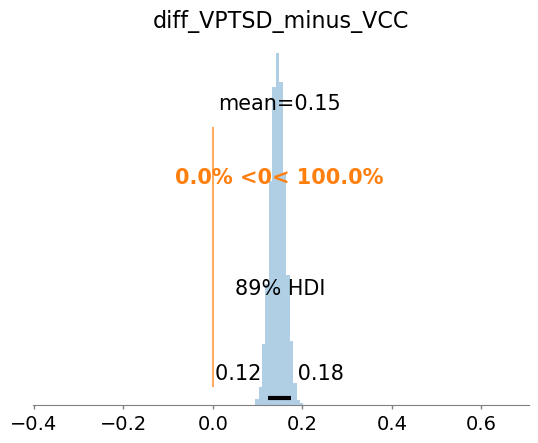

In [34]:
az.plot_posterior(idata, var_names=["diff_VPTSD_minus_VCC"], kind = 'hist', ref_val=0, hdi_prob=0.89)